In [34]:
import requests

slug = "presidential-election-winner-2024"
url = f"https://gamma-api.polymarket.com/events?slug={slug}"
data = requests.get(url).json()

# Print all markets (one per candidate)
for market in data[0]['markets']:
    print(market['conditionId'], market['question'])

0xdd22472e552920b8438158ea7238bfadfa4f736aa4cee91a6b86c39ead110917 Will Donald Trump win the 2024 US Presidential Election?
0x14018049e265a2d88f284be9588e2e3542e3a3df08ccdb344d28355dd7fdd8ef Will Joe Biden win the 2024 US Presidential Election?
0xced9f9d90c94db9f1e1dbd7d9fba82fe4fa7431c0d4e91e28896c8ac2d6acadd Will Nikki Haley win the 2024 US Presidential Election?
0x40bbdd26dc08406eedcb913efee7f7faddf50e16fc21caedb4972d57fd71e0d1 Will Gavin Newsom win the 2024 US Presidential Election?
0x7da35195ac3c7bf167f88ab0c27067a99020e36de67d39968b71d9debcdd925e Will Robert F. Kennedy Jr. win the 2024 US Presidential Election?
0xad6d309aaa500d96855996e84da00dfb2379548a693ca684d0877cf94fec05d1 Will Ron DeSantis win the 2024 US Presidential Election?
0x696baf880832d000a37ea87cc94235b1ac58e7e9fe7a144ccf5d141877629134 Will Vivek Ramaswamy win the 2024 US Presidential Election?
0xc6485bb7ea46d7bb89beb9c91e7572ecfc72a6273789496f78bc5e989e4d1638 Will Kamala Harris win the 2024 US Presidential Election?

In [12]:
import requests
import pandas as pd
import matplotlib.pyplot as plt

# ─── STEP 1: Fetch token_id via Gamma API (NOT conditionId!) ───
slug = "presidential-election-winner-2024"
gamma_url = f"https://gamma-api.polymarket.com/events?slug={slug}"
event = requests.get(gamma_url).json()[0]

# Print all candidates and their token IDs
for market in event['markets']:
    tokens = market.get('clobTokenIds', '[]')
    print(f"{market['question'][:50]} → tokens: {tokens}")

Will Donald Trump win the 2024 US Presidential Ele → tokens: ["21742633143463906290569050155826241533067272736897614950488156847949938836455", "48331043336612883890938759509493159234755048973500640148014422747788308965732"]
Will Joe Biden win the 2024 US Presidential Electi → tokens: ["88027839609243624193415614179328679602612916497045596227438675518749602824929", "34731657770883441140875001518098751138877095477683682718012432921110142479972"]
Will Nikki Haley win the 2024 US Presidential Elec → tokens: ["19083349462791593334532840548890602187185739923311385087650426802477691161360", "25663677275476030658483179785762851061160843737234225579491314980654272946621"]
Will Gavin Newsom win the 2024 US Presidential Ele → tokens: ["99200347365169760700385453164878188504479548439905371494493482364634358863823", "88063614818983277039870506697948521713429593096456892435153186054911641634952"]
Will Robert F. Kennedy Jr. win the 2024 US Preside → tokens: ["75551890681049796405776295654438099776333

In [14]:
event

{'id': '903193',
 'ticker': 'presidential-election-winner-2024',
 'slug': 'presidential-election-winner-2024',
 'title': 'Presidential Election Winner 2024',
 'description': 'This is a market on predicting the winner of the 2024 presidential election.',
 'resolutionSource': '',
 'startDate': '2024-01-04T22:58:00Z',
 'creationDate': '2024-01-04T23:04:57.844Z',
 'endDate': '2024-11-05T12:00:00Z',
 'image': 'https://polymarket-upload.s3.us-east-2.amazonaws.com/presidential-election-winner-2024-afdda358-219d-448a-abb5-ba4d14118d71.png',
 'icon': 'https://polymarket-upload.s3.us-east-2.amazonaws.com/presidential-election-winner-2024-afdda358-219d-448a-abb5-ba4d14118d71.png',
 'active': True,
 'closed': True,
 'archived': False,
 'new': False,
 'featured': False,
 'restricted': True,
 'volume': 3686335059.295466,
 'openInterest': 0,
 'sortBy': 'price',
 'published_at': '2024-01-04 17:33:51.448+00',
 'updatedBy': '15',
 'createdAt': '2024-01-04T17:33:51.47Z',
 'updatedAt': '2026-03-28T22:45:4

In [15]:
# ─── STEP 2: Select the correct token (Trump = Yes token) ───
import json

trump_market = next(
    m for m in event['markets'] 
    if 'Trump' in m['question']
)

# clobTokenIds contains [yes_token_id, no_token_id]
token_ids = json.loads(trump_market['clobTokenIds'])
trump_yes_token = token_ids[0]
print(f"Trump YES token_id: {trump_yes_token}")

Trump YES token_id: 21742633143463906290569050155826241533067272736897614950488156847949938836455


In [18]:
# ─── STEP 3: Fetch price history (correct approach for closed markets) ───
url = "https://clob.polymarket.com/prices-history"

params = {
    "market": trump_yes_token,   # ← token_id, NOT conditionId
    "interval": "max",           # ← required for closed markets
    "fidelity": 1440,            # ← in minutes: 1440 = daily, 720 = 12h
}

resp = requests.get(url, params=params).json()

# Debug: check what the API returns
print(resp.keys())
history = resp.get('history', resp)  # sometimes data is directly in root

dict_keys(['history'])


In [23]:
history[:5]

[{'t': 1704412803, 'p': 0.5},
 {'t': 1704499202, 'p': 0.405},
 {'t': 1704585602, 'p': 0.405},
 {'t': 1704672002, 'p': 0.475},
 {'t': 1704758403, 'p': 0.465}]

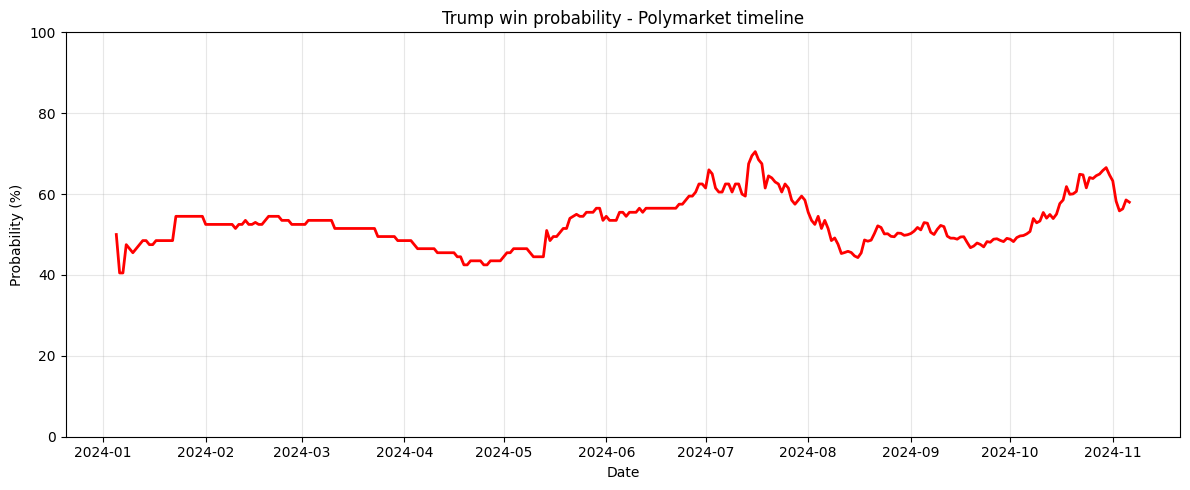

In [26]:
# ─── STEP 4: Visualize ───
df = pd.DataFrame(history)
df['date'] = pd.to_datetime(df['t'], unit='s')
df['probability'] = df['p'].astype(float)

plt.figure(figsize=(12, 5))
plt.plot(df['date'], df['probability'] * 100, color='red', linewidth=2)
plt.title("Trump win probability - Polymarket timeline")
plt.ylabel("Probability (%)")
plt.xlabel("Date")
plt.ylim(0, 100)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [27]:
df

,t,p,date,probability
0,1704412803,0.5000,2024-01-05 00:00:03,0.5000
1,1704499202,0.4050,2024-01-06 00:00:02,0.4050
2,1704585602,0.4050,2024-01-07 00:00:02,0.4050
3,1704672002,0.4750,2024-01-08 00:00:02,0.4750
4,1704758403,0.4650,2024-01-09 00:00:03,0.4650
...,...,...,...,...
302,1730505603,0.5825,2024-11-02 00:00:03,0.5825
303,1730592003,0.5585,2024-11-03 00:00:03,0.5585
304,1730678403,0.5635,2024-11-04 00:00:03,0.5635
305,1730764802,0.5855,2024-11-05 00:00:02,0.5855


Trump token:  21742633143463906290569050155826241533067272736897614950488156847949938836455
Harris token: 69236923620077691027083946871148646972011131466059644796654161903044970987404


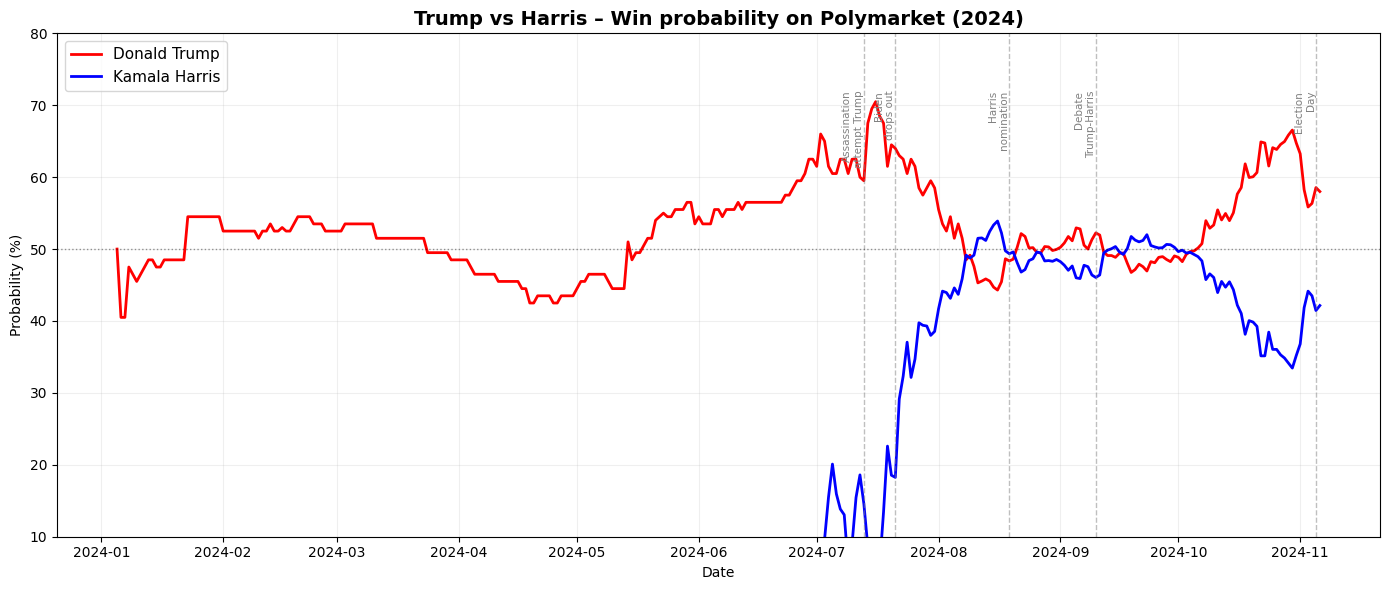

In [28]:
import requests
import json
import pandas as pd
import matplotlib.pyplot as plt

# ─── STEP 1: Fetch event data ───
slug = "presidential-election-winner-2024"
gamma_url = f"https://gamma-api.polymarket.com/events?slug={slug}"
event = requests.get(gamma_url).json()[0]

# ─── STEP 2: Fetch token IDs for Trump and Harris ───
def get_yes_token(markets, name):
    market = next(m for m in markets if name in m['question'])
    token_ids = json.loads(market['clobTokenIds'])
    return token_ids[0]  # index 0 = Yes token

trump_token = get_yes_token(event['markets'], 'Trump')
harris_token = get_yes_token(event['markets'], 'Harris')

print(f"Trump token:  {trump_token}")
print(f"Harris token: {harris_token}")

# ─── STEP 3: Fetch price history ───
def get_price_history(token_id, label):
    url = "https://clob.polymarket.com/prices-history"
    params = {
        "market": token_id,
        "interval": "max",
        "fidelity": 1440,  # daily
    }
    resp = requests.get(url, params=params).json()
    history = resp.get('history', [])
    
    df = pd.DataFrame(history)
    df['date'] = pd.to_datetime(df['t'], unit='s')
    df['price'] = df['p'].astype(float) * 100  # convert to percentage
    df['candidate'] = label
    
    # Deduplicate: max per day (filters Yes/No duplicates)
    df['date_only'] = df['date'].dt.date
    df = df.groupby('date_only')['price'].max().reset_index()
    df.columns = ['date', 'price']
    df['candidate'] = label
    return df

trump_df  = get_price_history(trump_token,  'Donald Trump')
harris_df = get_price_history(harris_token, 'Kamala Harris')

# ─── STEP 4: Visualize ───
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(trump_df['date'],  trump_df['price'],  color='red',  linewidth=2, label='Donald Trump')
ax.plot(harris_df['date'], harris_df['price'], color='blue', linewidth=2, label='Kamala Harris')

# Key events
key_events = {
    '2024-07-13': 'Assassination\nattempt Trump',
    '2024-07-21': 'Biden\ndrops out',
    '2024-08-19': 'Harris\nnomination',
    '2024-09-10': 'Debate\nTrump-Harris',
    '2024-11-05': 'Election\nDay',
}

for date_str, label in key_events.items():
    ax.axvline(pd.Timestamp(date_str), color='gray', linestyle='--', alpha=0.5, linewidth=1)
    ax.text(pd.Timestamp(date_str), 72, label, rotation=90,
            fontsize=7.5, va='top', ha='right', color='gray')

ax.axhline(50, color='black', linestyle=':', alpha=0.4, linewidth=1)
ax.set_title("Trump vs Harris – Win probability on Polymarket (2024)", fontsize=14, fontweight='bold')
ax.set_ylabel("Probability (%)")
ax.set_xlabel("Date")
ax.set_ylim(10, 80)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

In [29]:
# ─── Combine Trump and Harris into one DataFrame ───
# fidelity=1440 → one price point per day at 00:00 UTC
# 00:00 UTC of day D = closing price of day D-1 in US time (≈ 19:00-20:00 EST)
# → shift date back by 1 day so the label matches the actual US trading day

def get_price_history_full(token_id, label):
    url = "https://clob.polymarket.com/prices-history"
    params = {
        "market": token_id,
        "interval": "max",
        "fidelity": 1440,  # one point per day at 00:00 UTC
    }
    resp = requests.get(url, params=params).json()
    history = resp.get('history', [])

    df = pd.DataFrame(history)
    df['datetime_utc'] = pd.to_datetime(df['t'], unit='s')
    df['probability']  = df['p'].astype(float) * 100

    # Correct date label: 00:00 UTC day D → closing price of day D-1 (US time)
    df['date'] = (df['datetime_utc'] - pd.Timedelta(days=1)).dt.normalize()

    return df[['date', 'probability']].rename(columns={'probability': label})

trump_df  = get_price_history_full(trump_token,  'Trump (%)')
harris_df = get_price_history_full(harris_token, 'Harris (%)')

# Merge on date (outer join to preserve all data)
combined_df = pd.merge(trump_df, harris_df, on='date', how='outer')
combined_df = combined_df.sort_values('date').reset_index(drop=True)

# Round to 2 decimal places
combined_df['Trump (%)']  = combined_df['Trump (%)'].round(2)
combined_df['Harris (%)'] = combined_df['Harris (%)'].round(2)

print(combined_df)
print(f"\nShape: {combined_df.shape}")

          date  Trump (%)  Harris (%)
0   2024-01-04      50.00         NaN
1   2024-01-05      40.50        3.15
2   2024-01-06      40.50        2.70
3   2024-01-07      47.50        2.40
4   2024-01-08      46.50        2.30
..         ...        ...         ...
302 2024-11-01      58.25       41.85
303 2024-11-02      55.85       44.15
304 2024-11-03      56.35       43.50
305 2024-11-04      58.55       41.45
306 2024-11-05      58.00       42.15

[307 rows x 3 columns]

Shape: (307, 3)


In [30]:
# Filter from July 5 onwards (start of relevant campaign period)
final_dependent = combined_df[combined_df['date'] >= '2024-07-05'].reset_index(drop=True)
print(final_dependent)

          date  Trump (%)  Harris (%)
0   2024-07-05      60.50       15.95
1   2024-07-06      62.50       13.85
2   2024-07-07      62.50       13.05
3   2024-07-08      60.50        6.05
4   2024-07-09      62.50        9.05
..         ...        ...         ...
119 2024-11-01      58.25       41.85
120 2024-11-02      55.85       44.15
121 2024-11-03      56.35       43.50
122 2024-11-04      58.55       41.45
123 2024-11-05      58.00       42.15

[124 rows x 3 columns]


In [31]:
final_dependent.dtypes

date          datetime64[ns]
Trump (%)            float64
Harris (%)           float64
dtype: object

In [32]:
import os

output_path = "../../Data/1_Bronze/Polymarket/polymarket_win_probabilities.csv"
final_dependent.to_csv(output_path, index=False)
print(f"Saved {len(final_dependent)} rows to {output_path}")

Saved 124 rows to ../../Data/1_Bronze/Polymarket/polymarket_win_probabilities.csv


Get all candidates for Juli

In [33]:
# ─── get probability history for all candidates ───
def get_price_history_full(token_id, label):
    url = "https://clob.polymarket.com/prices-history"
    params = {
        "market": token_id,
        "interval": "max",
        "fidelity": 1440,
    }
    resp = requests.get(url, params=params).json()
    history = resp.get('history', [])
    if not history:
        return pd.DataFrame(columns=['date', label])
    
    df = pd.DataFrame(history)
    df['date'] = pd.to_datetime(df['t'], unit='s')
    df['date'] = df['date'].dt.normalize()  
    df = df.groupby('date')['p'].max().reset_index()
    df['p'] = df['p'].astype(float) * 100
    df = df.rename(columns={'p': label})
    return df

# Loop over all candidates
all_dfs = []
for market in event['markets']:
    try:
        name = market['question'].replace("Will ", "").replace(" win the 2024 US Presidential Election?", "")
        token_ids = json.loads(market['clobTokenIds'])
        yes_token = token_ids[0]
        df = get_price_history_full(yes_token, name)
        all_dfs.append(df)
        print(f"✓ {name}")
    except Exception as e:
        print(f"✗ {name}: {e}")

✓ Donald Trump
✓ Joe Biden
✓ Nikki Haley
✓ Gavin Newsom
✓ Robert F. Kennedy Jr.
✓ Ron DeSantis
✓ Vivek Ramaswamy
✓ Kamala Harris
✓ Chris Christie
✓ Elizabeth Warren
✓ Bernie Sanders
✓ AOC
✓ any other Democratic Politician
✓ any other Republican Politician
✓ Kanye West
✓ Michelle Obama
✓ Hillary Clinton


In [34]:
# ─── All candidates in one dataframe ───
from functools import reduce

combined_all = reduce(lambda left, right: pd.merge(left, right, on='date', how='outer'), all_dfs)
combined_all = combined_all.sort_values('date').reset_index(drop=True)
combined_all = combined_all.round(2)

print(combined_all)

          date  Donald Trump  Joe Biden  Nikki Haley  Gavin Newsom  \
0   2024-01-05         50.00      50.00        50.00         50.00   
1   2024-01-06         40.50      36.50         8.50          5.00   
2   2024-01-07         40.50      36.50         8.50          4.50   
3   2024-01-08         47.50      33.50         6.50          3.50   
4   2024-01-09         46.50      34.50         5.50          3.40   
..         ...           ...        ...          ...           ...   
302 2024-11-02         58.25       0.05         0.05          0.05   
303 2024-11-03         55.85       0.05         0.05          0.05   
304 2024-11-04         56.35       0.05         0.05          0.05   
305 2024-11-05         58.55       0.05         0.05          0.05   
306 2024-11-06         58.00       0.05         0.05          0.05   

     Robert F. Kennedy Jr.  Ron DeSantis  Vivek Ramaswamy  Kamala Harris  \
0                    50.00           NaN              NaN            NaN   
1      

In [37]:
# ─── STEP 1: Filter to July 2024 ───
july_df = combined_all[
    (combined_all['date'] >= '2024-07-01') & 
    (combined_all['date'] <= '2024-07-31')
].copy()

# ─── STEP 2: Find top candidates by mean win probability in July ───
# Get all candidate columns (everything except 'date')
candidate_cols = [col for col in july_df.columns if col != 'date']

# Calculate mean win probability per candidate in July
july_means = july_df[candidate_cols].mean()

# Pick top N candidates (e.g. top 6) by average probability
N = 6
top_candidates = july_means.nlargest(N).index.tolist()

print("Top candidates:", top_candidates)
print("\nJuly means:\n", july_means[top_candidates].round(2))

Top candidates: ['Donald Trump', 'Kamala Harris', 'Joe Biden', 'any other Democratic Politician', 'Michelle Obama', 'Gavin Newsom']

July means:
 Donald Trump                       62.61
Kamala Harris                      20.03
Joe Biden                           9.37
any other Democratic Politician     3.00
Michelle Obama                      2.81
Gavin Newsom                        1.34
dtype: float64


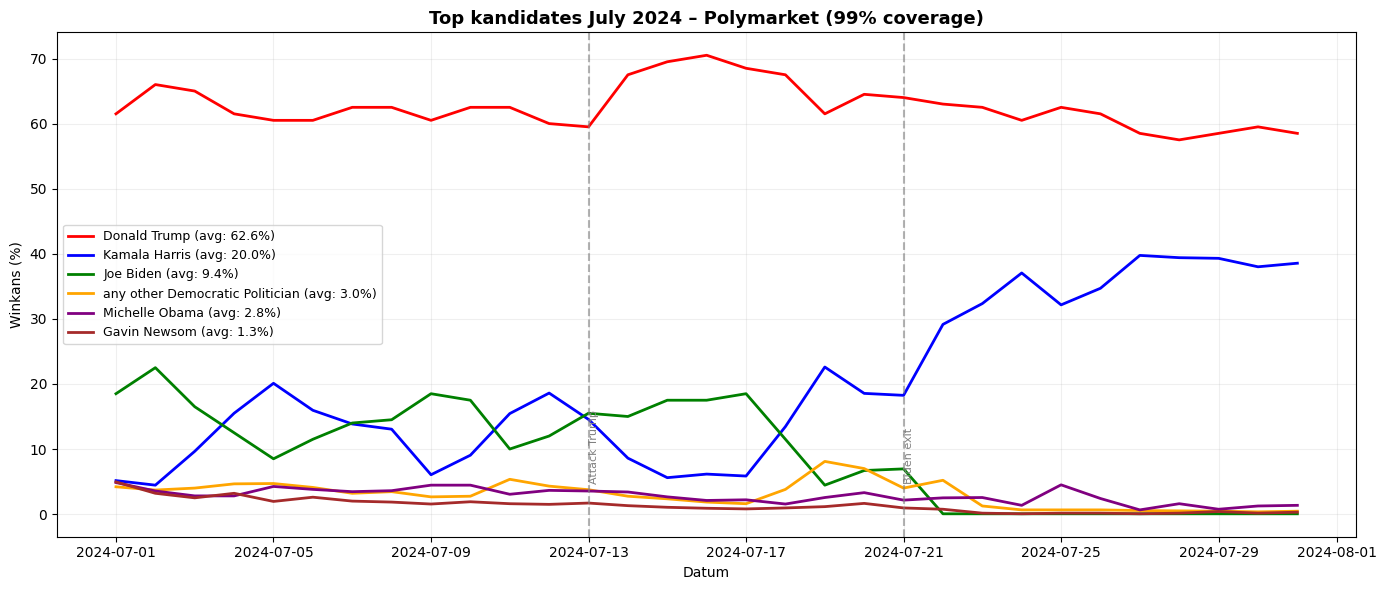

In [43]:
# ─── Visualize top candidates in July ───
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(14, 6))

colors = ['red', 'blue', 'green', 'orange', 'purple', 'brown']
for i, candidate in enumerate(top_candidates):
    ax.plot(july_df['date'], july_df[candidate], 
            label=f"{candidate} (avg: {july_means[candidate]:.1f}%)",
            linewidth=2, color=colors[i % len(colors)])

# Key events in july
ax.axvline(pd.Timestamp('2024-07-13'), color='gray', linestyle='--', alpha=0.6)
ax.text(pd.Timestamp('2024-07-13'), 5, 'Attack Trump', rotation=90, fontsize=8, color='gray')

ax.axvline(pd.Timestamp('2024-07-21'), color='gray', linestyle='--', alpha=0.6)
ax.text(pd.Timestamp('2024-07-21'), 5, 'Biden exit', rotation=90, fontsize=8, color='gray')

ax.set_title("Top kandidates July 2024 – Polymarket (99% coverage)", fontsize=13, fontweight='bold')
ax.set_ylabel("Winkans (%)")
ax.set_xlabel("Datum")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

In [44]:
output_path = "../../Data/1_Bronze/Polymarket/polymarket_july.csv"
july_df.to_csv(output_path, index=False)
print(f"Saved {len(july_df)} rows to {output_path}")

Saved 31 rows to ../../Data/1_Bronze/Polymarket/polymarket_july.csv


Compare July dataframe with final dataset dataframe

In [51]:
july_df.head(10)

,date,Donald Trump,Joe Biden,Nikki Haley,Gavin Newsom,Robert F. Kennedy Jr.,Ron DeSantis,Vivek Ramaswamy,Kamala Harris,Chris Christie,Elizabeth Warren,Bernie Sanders,AOC,any other Democratic Politician,any other Republican Politician,Kanye West,Michelle Obama,Hillary Clinton
178,2024-07-01,61.5,18.5,0.25,4.95,2.30,0.15,0.05,5.15,0.05,0.05,0.05,0.05,4.20,0.35,0.05,4.85,0.40
179,2024-07-02,66.0,22.5,0.25,3.20,1.70,0.20,0.05,4.45,0.05,0.05,0.05,0.05,3.70,0.40,0.05,3.55,0.35
180,2024-07-03,65.0,16.5,0.15,2.50,1.70,0.15,0.05,9.65,0.05,0.05,0.05,0.05,4.00,0.55,0.05,2.80,0.25
181,2024-07-04,61.5,12.5,0.15,3.20,2.05,0.15,0.05,15.50,0.05,0.05,0.05,0.05,4.65,0.55,0.05,2.80,0.30
182,2024-07-05,60.5,8.5,0.15,1.95,1.75,0.15,0.05,20.10,0.05,0.05,0.05,0.05,4.70,0.45,0.05,4.25,0.40
183,2024-07-06,60.5,11.5,0.15,2.60,1.45,0.15,0.05,15.95,0.05,0.05,0.05,0.05,4.10,0.45,0.05,3.80,0.45
184,2024-07-07,62.5,14.0,0.15,2.00,1.95,0.15,0.05,13.85,0.05,0.05,0.05,0.05,3.20,0.55,0.05,3.45,0.35
185,2024-07-08,62.5,14.5,0.15,1.85,1.75,0.15,0.05,13.05,0.05,0.05,0.05,0.05,3.45,0.35,0.05,3.60,0.45
186,2024-07-09,60.5,18.5,0.15,1.55,1.50,0.15,0.05,6.05,0.05,0.05,0.05,0.05,2.65,0.35,0.05,4.45,0.45
187,2024-07-10,62.5,17.5,0.15,1.90,1.60,0.15,0.05,9.05,0.05,0.05,0.05,0.05,2.75,0.35,0.05,4.45,0.60


In [49]:
final_dependent.head()

,date,Trump (%),Harris (%)
0,2024-07-05,60.5,15.95
1,2024-07-06,62.5,13.85
2,2024-07-07,62.5,13.05
3,2024-07-08,60.5,6.05
4,2024-07-09,62.5,9.05
